In [23]:
import numpy as np
import pandas as pd
import mne
import os
from datetime import datetime
from mne.channels import make_standard_montage
from sklearn.decomposition import PCA
import pickle
import matplotlib.pyplot as plt

In [2]:
def add_three_hours(timestamp):
    k = timestamp.split('T')
    k[1]= str(int(k[1][:2])+3)+k[1][2:]
    return 'T'.join(k)

def mp(c):
    """Convert log color markers to valid Plotly colors"""
    if c.strip()=="'blue'":
        return 'blue'
    if c.strip()=="'lightblue'":
        return 'red'
    return 'black'

def eeg_only(df):
    eeg_cols = [col for col in df.columns if (col.startswith('EEG.')) and col not in ['EEG.Counter', 'EEG.RawCq']]
    return df[eeg_cols]

def alt_pipeline(file_path):
    df = pd.read_csv(file_path)
    df.drop(columns=["EEG.Interpolated", "OriginalTimestamp", "EEG.MarkerHardware", "EEG.BatteryPercent", "MOT.CounterMems", "MOT.InterpolatedMems", 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY',
        'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ', "EEG.Battery", "EQ.SampleRateQuality", "PM.Engagement.IsActive", "PM.Excitement.IsActive", "PM.Stress.IsActive", "PM.Relaxation.IsActive", "PM.Interest.IsActive",'MC.Action', 'MC.ActionPower', 'MC.IsActive', 'CQ.AF3', 'CQ.F7', 'CQ.F3', 'CQ.FC5', 'CQ.T7', 'CQ.P7', 'CQ.O1',
        'CQ.O2', 'CQ.P8', 'CQ.T8', 'CQ.FC6', 'CQ.F4', 'CQ.F8', 'CQ.AF4',
        'CQ.Overall', 'EQ.OVERALL', 'EQ.AF3', 'EQ.F7', 'EQ.F3', 'EQ.FC5', 'EQ.T7', 'EQ.P7',
        'EQ.O1', 'EQ.O2', 'EQ.P8', 'EQ.T8', 'EQ.FC6', 'EQ.F4', 'EQ.F8', 'MarkerType', 'MarkerIndex', 'MarkerValueInt',
        'EQ.AF4'], inplace=True, errors='ignore')
    
    try:
        timestamps = pd.to_numeric(df['Timestamp'], errors='coerce')
        timestamps = timestamps[~np.isnan(timestamps)]
        if len(timestamps) > 1:
                sfreq = 1.0 / np.median(np.diff(timestamps))
                if not (10 < sfreq < 1000):
                    print(f"Warning: Calculated sfreq ({sfreq:.2f} Hz) seems unusual. Falling back to 128 Hz.")
                    sfreq = 128.0
        else:
                print("Warning: Not enough valid 'Timestamp' values to calculate sfreq. Falling back to 128 Hz.")
                sfreq = 128.0
    except Exception as e:
        print(f"Warning: Error processing 'Timestamp' column: {e}. Falling back to 128 Hz.")
        sfreq = 128.0
    df.index = df['Timestamp']
    start_timestamp = df['Timestamp'].iloc[0]
    df.drop("Timestamp", axis=1,inplace=True)
    return df, sfreq, start_timestamp

event_id = {
    'covert_speech': 1,
    'overt_speech': 2,
    'fixation': 3,
}

In [3]:

files_256 = [
    "Mariam Alzoubi1748421044458_EPOCX_211983_2025.05.28T11.30.46+03.00.md.pm.bp.mc.fe.csv",
    "Kinda Mashal1748955877058_EPOCX_211983_2025.06.03T16.04.38+03.00.md.pm.bp.mc.fe.csv",
    "Rama Bashar1748353496467_EPOCX_211983_2025.05.27T16.44.57+03.00.md.pm.bp.mc.fe.csv",
    "Malak Tamimi1748951740528_EPOCX_211983_2025.06.03T14.55.41+03.00.md.pm.bp.mc.fe.csv",
    "Mohammad Shahwan1748424849832_EPOCX_211983_2025.05.28T12.34.11+03.00.md.pm.bp.mc.fe.csv",
    "Rama Bashar1748352682130_EPOCX_211983_2025.05.27T16.31.24+03.00.md.pm.bp.mc.fe.csv",
    "mohammad jaradat1750242921892_EPOCX_211983_2025.06.18T13.35.24+03.00.md.pm.bp.mc.fe.csv",
    "Kinda Mashal1748954273361_EPOCX_211983_2025.06.03T15.37.54+03.00.md.pm.bp.mc.fe.csv",
    "Mohammad Shahwan1748426328305_EPOCX_211983_2025.05.28T12.58.49+03.00.md.pm.bp.mc.fe.csv",
    "Kinda Mashal1748955054298_EPOCX_211983_2025.06.03T15.50.55+03.00.md.pm.bp.mc.fe.csv",
    "Mohammad Shahwan1748424068255_EPOCX_211983_2025.05.28T12.21.10+03.00.md.pm.bp.mc.fe.csv",
    "mohammad jaradat1750242146773_EPOCX_211983_2025.06.18T13.22.28+03.00.md.pm.bp.mc.fe.csv",
    "Mariam Alzoubi1748421900422_EPOCX_211983_2025.05.28T11.45.02+03.00.md.pm.bp.mc.fe.csv",
    "Malak Tamimi1748952464968_EPOCX_211983_2025.06.03T15.07.46+03.00.md.pm.bp.mc.fe.csv",
    "Malak Tamimi1748950961776_EPOCX_211983_2025.06.03T14.42.43+03.00.md.pm.bp.mc.fe.csv",
    "Aws Safi1742290353356_EPOCX_211983_2025.03.18T12.32.34+03.00.md.pm.bp.csv",
    "Khaled Abu Qteish1742217278209_EPOCX_211983_2025.03.17T16.14.39+03.00.md.pm.bp.csv",
    "Mohammad Tarshihi1742897131405_EPOCX_211983_2025.03.25T13.05.32+03.00.md.pm.bp.csv",
    "Aws Safi1742289648917_EPOCX_211983_2025.03.18T12.20.50+03.00.md.pm.bp.csv",
    "Aws Safi1742291163364_EPOCX_211983_2025.03.18T12.46.04+03.00.md.pm.bp.csv",
    "Mohammad Tarshihi1742896030991_EPOCX_211983_2025.03.25T12.47.12+03.00.md.pm.bp.csv",
    "Mohammad Tarshihi1742898052037_EPOCX_211983_2025.03.25T13.20.53+03.00.md.pm.bp.csv",
    

]

In [4]:
logs_l = []
for l in files_256:
    log_file = os.path.join("data_logs",l.split("1")[0], l.split("1")[0]+"_run"+l[l.find("1"):l.find("_EPOCX")]+".txt")
    logs_l.append(log_file)
    
logs = {}
for log_file in logs_l:
    if not log_file.endswith('.txt'):
        continue
    identifier = log_file.split("_run")[1].split(".")[0]
    try:
        with open(f"{log_file}", "r") as f:
            a = f.readlines()
            if not a:
                print(f"WARNING: Empty log file: {log_file}")
                continue
            logs[identifier] = [
                (datetime.strptime(add_three_hours(line.split(" ")[0]), "[%Y-%m-%dT%H:%M:%S.%fZ]").timestamp(),
                mp(line.split(" ")[-1]),
                " ".join(line.split(" ")[2:]))
                for line in a
                if 'blue' in line or '+' in line
            ]
    except Exception as e:
        print(f"ERROR parsing log file {log_file}: {str(e)}")

In [5]:
processed_l = []
exclude = [
[ 0 ],
[ 0,1,4,12 ],
[ 1,10 ],
[ 7, 9, 11 ],
[ 1,2, 6, 13 ],
[ 1,2,3,13 ],
[ 12 ],
[ 0,3,9 ],
[ 0,1 ],
[ 10 ],
[ 0,2,4,7 ],
[ 0,4,13 ],
[],
[ 6,9,13 ],
[ 0,1,4,7 ],
[2,3],
[0,1,5],
[0],
[0,1,4,9],
[5],
[0],
[0,8]
]
for i,file in enumerate(files_256):
    p, sf, st = alt_pipeline(os.path.join("data", file))
    p = eeg_only(p)
    d = p.values.T
    ch_names = [name.split('.')[1] for name in p.columns.tolist()]
    inf = mne.create_info(ch_names=ch_names, sfreq=sf, ch_types=(['eeg']*len([i for i in p.columns if i.startswith('EEG.')]))+['bio']*len([i for i in p.columns if i.startswith('FE.')]))
    r = mne.io.RawArray(d, inf, verbose=False)
    r._data = r._data - np.mean(r._data, axis=1, keepdims=True)
    mont = make_standard_montage('standard_1020')
    r.set_montage(mont, match_case=False, on_missing='warn')
    
    ev = []
    raw_ind = p.index

    for timestamp, color, description in logs[file.split("_")[0][file.split("_")[0].find("1"):]]:
        sample_idx = np.searchsorted(raw_ind, timestamp)

        if sample_idx >= len(raw_ind) or sample_idx < 0:
            continue
            
        if color == 'blue':
            event_type = event_id['covert_speech']
        elif color == 'red':
            event_type = event_id['overt_speech']
        elif color == 'black':
            event_type = event_id['fixation']
        else:
            continue  
        ev.append([sample_idx, 0, event_type])

    ev = np.array(ev, dtype=int)

    r.filter(1, 64, fir_design="firwin")
    r_d = r.get_data() * 1e-6
    r._data = r_d
    rej = dict(eeg=200e-6)
    ep = mne.Epochs(r, ev, reject=rej, event_id=event_id, picks='eeg', event_repeated='drop')
    ic = mne.preprocessing.ICA(n_components=14, method='picard', random_state=15)
    ic.fit(r)
    print(f"Fitted ICA for {file}")
    # ic.plot_sources(r)
    ic.apply(r, exclude=exclude[i])
    pca = PCA(n_components=14).fit(r.get_data().T)
    pcs = pca.transform(r.get_data().T).T
    epo_clean = mne.Epochs(r, ev, reject=rej, event_id=event_id, picks='eeg', event_repeated='drop')

    processed_l.append({"processed": p, "sfreq": sf, "start_timestamp": st, "raw": r, "events": ev, "epochs": ep, "epochs_cleaned": epo_clean, "pca": pcs})

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 64 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 64.00 Hz
- Upper transition bandwidth: 16.00 Hz (-6 dB cutoff frequency: 72.00 Hz)
- Filter length: 847 samples (3.307 s)

Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
582 matching events found
Setting baseline interval to [-0.19910931587219238, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Fitting ICA to data using 14 channels (please be patient, this may take a while)
Selecting by number: 14 components
Fitting ICA took 22.8s.
Fitted ICA for M

In [60]:
r._data.shape

(14, 86647)

In [61]:
np.mean(r._data, axis=1).shape

(14,)

In [ ]:
# with open("processed_data_pca.pkl", "wb") as f:
#     pickle.dump(processed_l, f)

In [ ]:
with open("processed_data_pca.pkl", "rb") as f:
    processed_l = pickle.load(f)

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F
from collections import defaultdict
import re

In [89]:
def extract_word_events(logs, identifier=None, words=('up', 'down', 'left', 'right')):
    word_events = defaultdict(lambda: {'covert': [], 'overt': [], 'fixation': []})
    logs_list = logs["1748950961776"] if not identifier else logs[identifier]
    i = 0
    while i < len(logs_list):
        timestamp, color, desc = logs_list[i]
        match = re.search(r"display to '(\w+)'", desc)
        if match:
            word = match.group(1).lower()
            if word in words:
                if color == 'red':
                    word_events[word]['covert'].append(timestamp)
                elif color == 'blue':
                    word_events[word]['overt'].append(timestamp)
        elif 'cross' in desc and color == 'black':
            j = i + 1
            while j < len(logs_list):
                next_timestamp, next_color, next_desc = logs_list[j]
                next_match = re.search(r"display to '(\w+)'", next_desc)
                if next_match:
                    next_word = next_match.group(1).lower()
                    if next_word in words:
                        word_events[next_word]['fixation'].append(timestamp)
                        break
                j += 1
        i += 1
    return word_events

def extract_gamma(raw, word_events, start_timestamp, tmin=-0.4, tmax=0.8, sfreq=128, second_band=None):
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 12),
        'beta': (12, 30),
        'gamma': (30, 64)
    }
    filtered_raw = raw.copy().filter(bands['gamma'][0], bands['gamma'][1], fir_design='firwin')
    if second_band:
        filtered_raw_second = raw.copy().filter(bands[second_band][0], bands[second_band][1], fir_design='firwin')
    X = []
    y = []
    
    label_map = {'up': 0, 'down': 1, 'left': 2, 'right': 3}
    # label_map = {'up': 0, 'down': 0, 'left': 1, 'right': 1}
    print(raw.info["ch_names"], filtered_raw.info["ch_names"], raw._data.shape, filtered_raw._data.shape, word_events)
    for word in ['up', 'down', 'left', 'right']:
        # for event_type in ['covert', 'overt']:
        for event_type in ['covert']:
            event_times = word_events[word][event_type]
            for t in event_times:
                idx = np.searchsorted(filtered_raw.times, t-start_timestamp)
                start = int(idx + tmin * sfreq)
                end = int(idx + tmax * sfreq)
                
                if start >= 0 and end < filtered_raw._data.shape[1]:
                    epoch_data = filtered_raw._data[:, start:end]
                    if second_band:
                        epoch_data_theta = filtered_raw_second._data[:, start:end]
                        epoch_data = np.vstack((epoch_data, epoch_data_theta))
                    X.append(epoch_data)
                    y.append(label_map[word])
                else:
                    print(f"Skipping epoch for {word} at {t} (out of bounds)")
    
    return np.array(X), np.array(y)

for band in ['delta', 'theta', 'alpha', 'beta']:

    ch_names = [name.split('.')[1] for name in processed_l[0]["processed"].columns.tolist()]
    inf = mne.create_info(ch_names=ch_names, sfreq=processed_l[0]["sfreq"], ch_types=(['eeg']*len([i for i in processed_l[0]["processed"].columns if i.startswith('EEG.')]))+['bio']*len([i for i in processed_l[0]["processed"].columns if i.startswith('FE.')]))
    raw = mne.io.RawArray(processed_l[0]["pca"], inf, verbose=False)
    mont = make_standard_montage('standard_1020')
    raw.set_montage(mont, match_case=False, on_missing='warn')
    # X, y = extract_gamma(processed_l[0]["raw"], extract_word_events(logs, identifier=files_256[0].split("_")[0][files_256[0].split("_")[0].find("1"):], words=['up', 'down', 'left', 'right']), start_timestamp=processed_l[0]["start_timestamp"], sfreq=processed_l[0]["sfreq"], second_band=band)
    X, y = extract_gamma(raw, extract_word_events(logs, identifier=files_256[0].split("_")[0][files_256[0].split("_")[0].find("1"):], words=['up', 'down', 'left', 'right']), start_timestamp=processed_l[0]["start_timestamp"], sfreq=processed_l[0]["sfreq"], second_band=band)
    if X.shape[2] > 200:
        X = X[:, :, ::2]
    print(X.shape, y.shape)

    for i, item in enumerate(processed_l[1:]):
        # raw = item["raw"]
        ch_names = [name.split('.')[1] for name in item["processed"].columns.tolist()]
        inf = mne.create_info(ch_names=ch_names, sfreq=item["sfreq"], ch_types=(['eeg']*len([i for i in item["processed"].columns if i.startswith('EEG.')]))+['bio']*len([i for i in item["processed"].columns if i.startswith('FE.')]))
        raw = mne.io.RawArray(item["pca"], inf, verbose=False)
        mont = make_standard_montage('standard_1020')
        raw.set_montage(mont, match_case=False, on_missing='warn')

        word_events = extract_word_events(logs, identifier=files_256[i+1].split("_")[0][files_256[i+1].split("_")[0].find("1"):], words=['up', 'down', 'left', 'right'])
        sfreq = item["sfreq"]
        X_item, y_item = extract_gamma(raw, word_events, start_timestamp=item["start_timestamp"], sfreq=sfreq, second_band=band)
        if X_item.shape[2] > 200:
            X_item = X_item[:, :, ::2]
        print(X_item.shape, y_item.shape)
        X = np.concatenate((X, X_item), axis=0)
        y = np.concatenate((y, y_item), axis=0)

    np.savez_compressed(f"gamma_{band}_pca.npz", X=X, y=y)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 30 - 64 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 30.00
- Lower transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 26.25 Hz)
- Upper passband edge: 64.00 Hz
- Upper transition bandwidth: 16.00 Hz (-6 dB cutoff frequency: 72.00 Hz)
- Filter length: 113 samples (0.441 s)



Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 1691 samples (6.602 s)

['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4'] ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4'] (14, 173221) (14, 173221) defaultdict(<function extract_word_events.<locals>.<lambda> at 0x143ed5ee0>, {'right': {'covert': [1748421047.392, 1748421171.292, 1748421208.159, 1748421306.276, 1748421327.792, 1748421400.209, 1748421493.194, 1748421565.993, 174842161

In [ ]:
def augment_with_noise(X, y, n_augment=2, noise_level=0.05):
    X_aug = []
    y_aug = []
    
    for i in range(len(X)):
        X_aug.append(X[i])
        y_aug.append(y[i])
        
        for _ in range(n_augment):
            baseline = np.mean(np.abs(X[i]))
            noise = np.random.normal(0, baseline * noise_level, X[i].shape)
            X_aug.append(X[i] + noise)
            y_aug.append(y[i])
    
    return np.array(X_aug), np.array(y_aug)

In [17]:
X, y = augment_with_noise(X, y, n_augment=2, noise_level=0.05)
print(f"Augmented shape: {X.shape}, {y.shape}")

Augmented shape: (1578, 14, 154), (1578,)


In [ ]:
np.savez_compressed("gamma_delta_no_pca.npz", X=X, y=y)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(X_test.shape[0], -1)).reshape(X_test.shape)

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

In [19]:
class CNN_LSTM_Classifier(nn.Module):
    def __init__(self, n_channels, n_timepoints, n_classes=4):
        super(CNN_LSTM_Classifier, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=n_channels, out_channels=28, groups=n_channels, kernel_size=16, padding='valid')
        self.conv2 = nn.Conv1d(in_channels=28, out_channels=56, groups=28, kernel_size=32, padding='valid')
        self.conv3 = nn.Conv1d(in_channels=56, out_channels=128, groups=1, kernel_size=32, padding='valid')

        self.pool = nn.AvgPool1d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(0.3)
        
        # self.lstm = nn.LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3)
        # self.dropout2 = nn.Dropout(0.5)
        
        self.classifier = nn.Linear(128, n_classes)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        
        x = F.relu(self.conv3(x))
        # x = self.pool(x)
        
        x = self.dropout1(x)
        
        # x = x.transpose(1, 2)
        
        # lstm_out, (h_n, c_n) = self.lstm(x)
        
        # x = lstm_out[:, -1, :]
        # flatten to go to linear layer
        x = x.mean(dim=2)
        # x = self.dropout2(x)
        x = self.classifier(x)
        
        return x

n_channels = X_train_tensor.shape[1]
n_timepoints = X_train_tensor.shape[2]
n_classes = 4

model = CNN_LSTM_Classifier(n_channels, n_timepoints, n_classes)
print(model)

CNN_LSTM_Classifier(
  (conv1): Conv1d(14, 28, kernel_size=(16,), stride=(1,), padding=valid, groups=14)
  (conv2): Conv1d(28, 56, kernel_size=(32,), stride=(1,), padding=valid, groups=28)
  (conv3): Conv1d(56, 128, kernel_size=(32,), stride=(1,), padding=valid)
  (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
  (dropout1): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=4, bias=True)
)


In [20]:
device = torch.device('cpu')
print(f"Using device: {device}")

X_train_tensor = X_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Using device: cpu


In [21]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)
    
    return total_loss / len(train_loader), 100. * correct / total

def test_epoch(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            
            all_preds.extend(pred.cpu().numpy().flatten())
            all_targets.extend(target.cpu().numpy())
    
    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    
    return test_loss, accuracy, all_preds, all_targets

num_epochs = 100
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = test_epoch(model, test_loader, criterion, device)
    
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
            f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

Epoch   0: Train Loss: 1.3418, Train Acc: 39.62%, Test Loss: 1.3366, Test Acc: 40.19%
Epoch  10: Train Loss: 1.1074, Train Acc: 51.90%, Test Loss: 1.1942, Test Acc: 47.47%
Epoch  20: Train Loss: 0.5571, Train Acc: 81.14%, Test Loss: 0.8940, Test Acc: 65.19%
Epoch  30: Train Loss: 0.1988, Train Acc: 95.64%, Test Loss: 0.5603, Test Acc: 85.44%
Epoch  40: Train Loss: 0.0653, Train Acc: 98.65%, Test Loss: 0.3823, Test Acc: 95.89%
Epoch  50: Train Loss: 0.0223, Train Acc: 99.92%, Test Loss: 0.3433, Test Acc: 97.15%
Epoch  60: Train Loss: 0.0138, Train Acc: 100.00%, Test Loss: 0.3828, Test Acc: 97.15%


KeyboardInterrupt: 


FINAL RESULTS - CNN-LSTM Directional Movement Classifier
Final Test Accuracy: 26.42%

Classification Report:
              precision    recall  f1-score   support

          up       0.23      0.24      0.23        21
        down       0.33      0.24      0.28        21
        left       0.05      0.05      0.05        21
       right       0.34      0.40      0.37        43

    accuracy                           0.26       106
   macro avg       0.24      0.23      0.23       106
weighted avg       0.26      0.26      0.26       106


Confusion Matrix:
[[ 5  1  8  7]
 [ 4  5  0 12]
 [ 3  3  1 14]
 [10  6 10 17]]


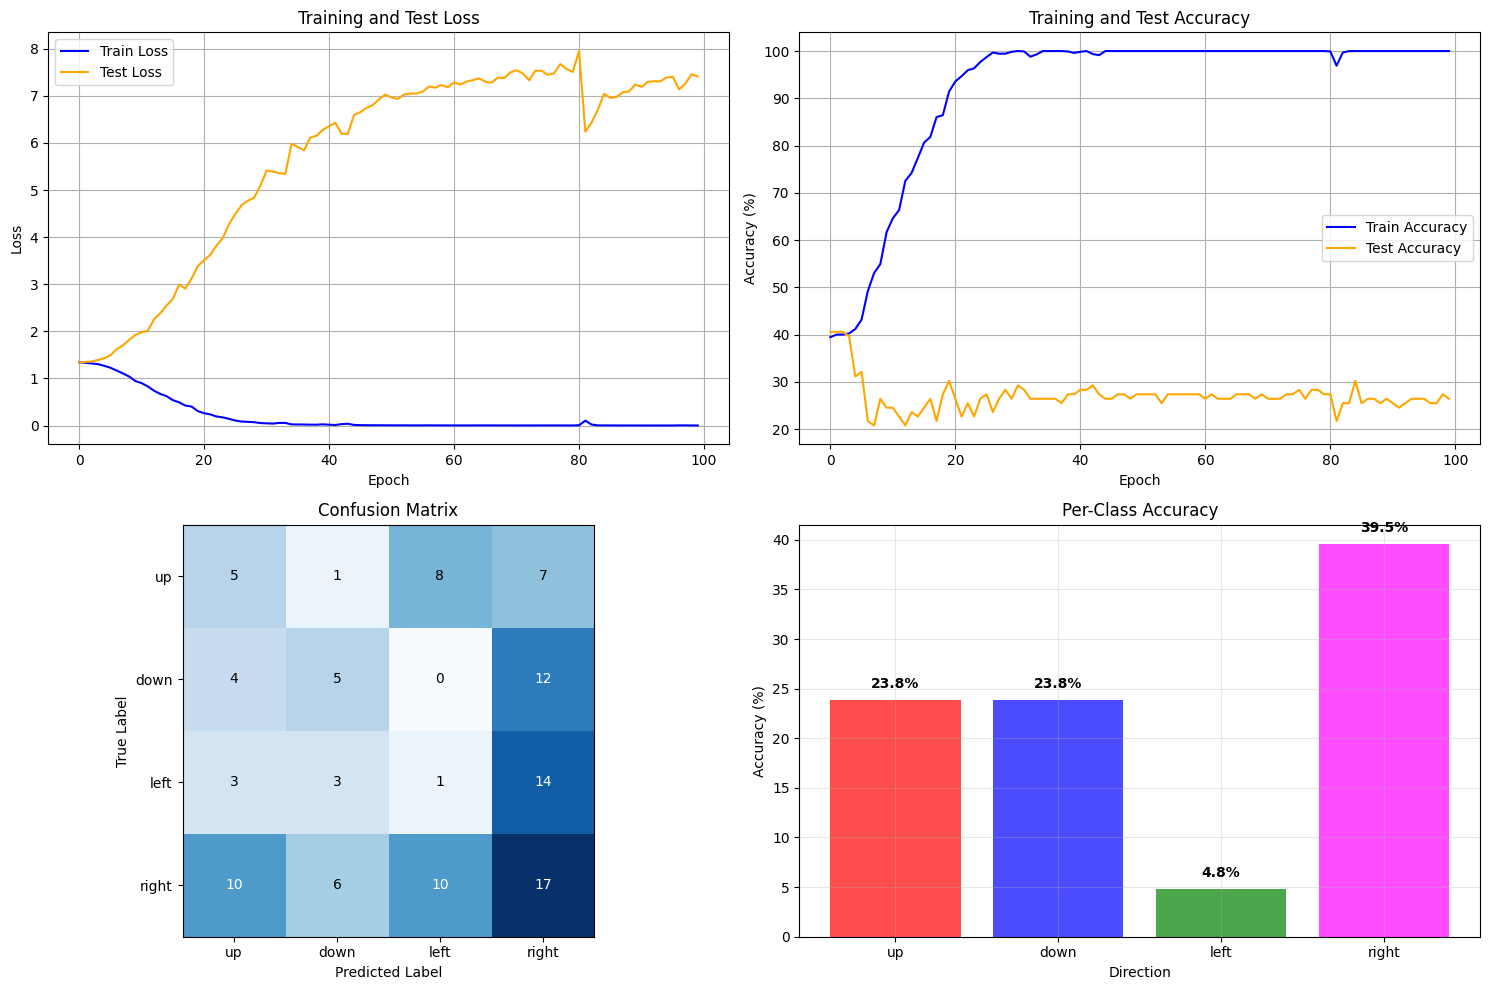


Per-class accuracy:
  UP: 23.8%
  DOWN: 23.8%
  LEFT: 4.8%
  RIGHT: 39.5%

Model Summary:
  - Input: 14 EEG channels, 154 time points
  - Gamma frequency band: 30-100 Hz
  - Architecture: 1D CNN + LSTM
  - Parameters: 232,344
  - Training epochs: 100
  - Final accuracy: 26.42%


In [59]:
_, final_test_acc, test_preds, test_targets = test_epoch(model2, test_loader, criterion, device)

print(f"\n{'='*60}")
print(f"FINAL RESULTS - CNN-LSTM Directional Movement Classifier")
print(f"{'='*60}")
print(f"Final Test Accuracy: {final_test_acc:.2f}%")

class_names = ['up', 'down', 'left', 'right']
print(f"\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=class_names))

print(f"\nConfusion Matrix:")
cm = confusion_matrix(test_targets, test_preds)
print(cm)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].plot(train_losses, label='Train Loss', color='blue')
axes[0,0].plot(test_losses, label='Test Loss', color='orange')
axes[0,0].set_title('Training and Test Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(train_accuracies, label='Train Accuracy', color='blue')
axes[0,1].plot(test_accuracies, label='Test Accuracy', color='orange')
axes[0,1].set_title('Training and Test Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].legend()
axes[0,1].grid(True)

im = axes[1,0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[1,0].set_title('Confusion Matrix')
tick_marks = np.arange(len(class_names))
axes[1,0].set_xticks(tick_marks)
axes[1,0].set_xticklabels(class_names)
axes[1,0].set_yticks(tick_marks)
axes[1,0].set_yticklabels(class_names)
axes[1,0].set_ylabel('True Label')
axes[1,0].set_xlabel('Predicted Label')

thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    axes[1,0].text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100
colors = ['red', 'blue', 'green', 'magenta']
bars = axes[1,1].bar(class_names, class_accuracy, color=colors, alpha=0.7)
axes[1,1].set_title('Per-Class Accuracy')
axes[1,1].set_xlabel('Direction')
axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].grid(True, alpha=0.3)

for i, (bar, acc) in enumerate(zip(bars, class_accuracy)):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nPer-class accuracy:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name.upper()}: {class_accuracy[i]:.1f}%")

print(f"\nModel Summary:")
print(f"  - Input: {n_channels} EEG channels, {n_timepoints} time points")
print(f"  - Gamma frequency band: 30-100 Hz")
print(f"  - Architecture: 1D CNN + LSTM")
print(f"  - Parameters: {sum(p.numel() for p in model2.parameters()):,}")
print(f"  - Training epochs: {num_epochs}")
print(f"  - Final accuracy: {final_test_acc:.2f}%")

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(X_test.shape[0], -1)).reshape(X_test.shape)
X_train_scaled, y_train_scaled = augment_with_noise(X_train_scaled, y_train, n_augment=2, noise_level=0.05)

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.LongTensor(y_train_scaled)
y_test_tensor = torch.LongTensor(y_test)

In [48]:
model2 = CNN_LSTM_Classifier(n_channels, n_timepoints, n_classes)

In [55]:


device = torch.device('cpu')
print(f"Using device: {device}")

X_train_tensor = X_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Using device: cpu


In [57]:
num_epochs = 100
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model2, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = test_epoch(model2, test_loader, criterion, device)

    scheduler.step()
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
            f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

Epoch   0: Train Loss: 1.3423, Train Acc: 39.44%, Test Loss: 1.3391, Test Acc: 40.57%
Epoch  10: Train Loss: 0.9019, Train Acc: 64.60%, Test Loss: 1.9812, Test Acc: 24.53%
Epoch  20: Train Loss: 0.2630, Train Acc: 93.57%, Test Loss: 3.5092, Test Acc: 26.42%
Epoch  30: Train Loss: 0.0481, Train Acc: 100.00%, Test Loss: 5.4116, Test Acc: 29.25%
Epoch  40: Train Loss: 0.0196, Train Acc: 99.84%, Test Loss: 6.3555, Test Acc: 28.30%
Epoch  50: Train Loss: 0.0064, Train Acc: 100.00%, Test Loss: 6.9644, Test Acc: 27.36%
Epoch  60: Train Loss: 0.0042, Train Acc: 100.00%, Test Loss: 7.2836, Test Acc: 26.42%
Epoch  70: Train Loss: 0.0036, Train Acc: 100.00%, Test Loss: 7.5432, Test Acc: 26.42%
Epoch  80: Train Loss: 0.0084, Train Acc: 99.92%, Test Loss: 7.9490, Test Acc: 27.36%
Epoch  90: Train Loss: 0.0033, Train Acc: 100.00%, Test Loss: 7.1905, Test Acc: 25.47%
Epoch  99: Train Loss: 0.0033, Train Acc: 100.00%, Test Loss: 7.4099, Test Acc: 26.42%
